In [ ]:
!pip install torchvision matplotlib --quiet


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataloader = DataLoader(
    datasets.MNIST(root='./data', train=True, transform=transform, download=True),
    batch_size=64,
    shuffle=True
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.9 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]


Epoch [1/20], D Loss: 0.1144, G Loss: 5.6874
Epoch [2/20], D Loss: 0.7919, G Loss: 1.7905
Epoch [3/20], D Loss: 0.4815, G Loss: 2.2496
Epoch [4/20], D Loss: 0.4115, G Loss: 2.2261
Epoch [5/20], D Loss: 0.5479, G Loss: 6.1192


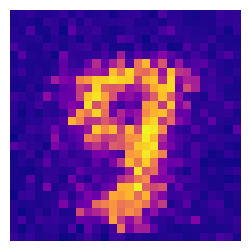

Epoch [6/20], D Loss: 0.2740, G Loss: 3.7522
Epoch [7/20], D Loss: 0.2898, G Loss: 4.4732
Epoch [8/20], D Loss: 0.4157, G Loss: 2.9479
Epoch [9/20], D Loss: 0.2705, G Loss: 3.8861
Epoch [10/20], D Loss: 0.4322, G Loss: 3.3564


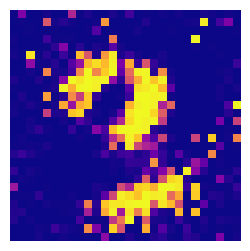

Epoch [11/20], D Loss: 0.6921, G Loss: 3.4336
Epoch [12/20], D Loss: 1.0630, G Loss: 1.8477
Epoch [13/20], D Loss: 0.6057, G Loss: 2.2461
Epoch [14/20], D Loss: 0.6016, G Loss: 1.8361
Epoch [15/20], D Loss: 0.4542, G Loss: 2.6438


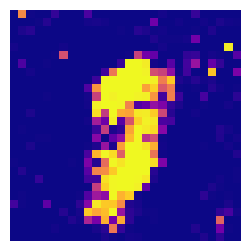

Epoch [16/20], D Loss: 0.8603, G Loss: 1.5630
Epoch [17/20], D Loss: 0.8488, G Loss: 2.0233
Epoch [18/20], D Loss: 0.9474, G Loss: 1.6850
Epoch [19/20], D Loss: 0.6322, G Loss: 1.7101
Epoch [20/20], D Loss: 0.7009, G Loss: 1.3843


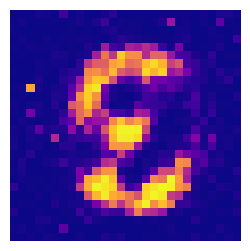

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(G.parameters(), lr=0.0002)
d_optimizer = optim.Adam(D.parameters(), lr=0.0002)

def show_generated_images():
    G.eval()
    z = torch.randn(1, 100).to(device)
    fake_image = G(z).view(1, 1, 28, 28).cpu().detach().squeeze()

    plt.figure(figsize=(3, 3))
    plt.imshow(fake_image, cmap='plasma')
    plt.axis('off')
    plt.show()

epochs = 20

for epoch in range(epochs):
    for real_images, _ in dataloader:
        batch_size = real_images.size(0)
        real_images = real_images.view(batch_size, -1).to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        z = torch.randn(batch_size, 100).to(device)
        fake_images = G(z)

        d_real_loss = criterion(D(real_images), real_labels)
        d_fake_loss = criterion(D(fake_images.detach()), fake_labels)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        z = torch.randn(batch_size, 100).to(device)
        fake_images = G(z)
        g_loss = criterion(D(fake_images), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

    if (epoch + 1) % 5 == 0:
        show_generated_images()

